# ABC-XYZ-Analysis

In [1]:
import polars as pl
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import scipy
import heapq
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt



## import data

In [2]:
data_folder = Path.cwd().parents[1] / 'data'

# --- ingestion: no data is read here; scan_csv only inspects the header ---
calendar_lf = pl.scan_csv(data_folder / 'calendar.csv')
prices_lf   = pl.scan_csv(data_folder / 'sell_prices.csv')
sales_lf    = pl.scan_csv(data_folder / 'sales_train_evaluation.csv')

In [3]:
STORE = ['CA_1', 'CA_2']

# collect_schema() reads the header only, it does not execute the plan.
day_cols  = [c for c in sales_lf.collect_schema().names() if c.startswith('d_')]
day_order = sorted(day_cols, key=lambda c: int(c.removeprefix('d_')))   # chronological, not lexical

# --- demand: wide daily matrix -> long (item_id, d, demand) + financial week ---
demand_lf = (
    sales_lf
    .filter(pl.col('store_id').is_in(STORE))          # predicate pushed into the scan
    .select(['item_id', *day_cols])
    .unpivot(index='item_id', on=day_cols, variable_name='d', value_name='demand')
    .join(calendar_lf.select('d', 'wm_yr_wk'), on='d', how='inner')
)

# --- prices: same store, join keys + price only (projection pushdown drops the rest) ---
prices_store_lf = (
    prices_lf
    .filter(pl.col('store_id').is_in(STORE))
    .select('item_id', 'wm_yr_wk', 'sell_price')
) 

# --- item-day fact table ---
merged_lf = (
    demand_lf
    .join(prices_store_lf, on=['item_id', 'wm_yr_wk'], how='inner')   # inner: drops unpriced item-weeks
    .with_columns(
        pl.col('item_id').str.split('_').list.slice(0, 2).list.join('_').alias('dept_id'),
        pl.col('d').str.split('_').list.get(-1).cast(pl.Int32).alias('day_n'),
    )
)

# --- department x day aggregate ---
dept_day_lf = (
    merged_lf
    .group_by('dept_id', 'day_n')
    .agg(
        pl.col('demand').sum().alias('total_demand'),
        (pl.col('demand') * pl.col('sell_price')).sum().alias('total_weighted_price'),
    )
    .with_columns(
        (pl.col('total_weighted_price') / pl.col('total_demand')).round(3).alias('price_avg')
    )
    .filter(pl.col('price_avg').is_not_nan())     # zero-demand department-days give 0/0
)

wide_df = (
    dept_day_lf
    .sort('day_n')                                # column order = order of first appearance
    .collect()
    .pivot(index='dept_id', on='day_n', values='total_weighted_price')
    .sort(by='dept_id')
)


In [4]:
wide_df

dept_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,…,1905,1906,1907,1908,1909,1910,1911,1912,1913,1914,1915,1916,1917,1918,1919,1920,1921,1922,1923,1924,1925,1926,1927,1928,1929,1930,1931,1932,1933,1934,1935,1936,1937,1938,1939,1940,1941
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""FOODS_1""",3181.04,3372.99,1976.99,1908.13,1919.22,2127.03,2700.2,2992.44,2806.59,2216.1,3451.83,2498.44,2946.11,3646.18,5104.07,5390.3,3039.76,2180.1,2300.78,2137.47,2984.92,3219.3,3475.54,3008.12,1881.99,2529.24,2310.0,2736.01,4123.11,2946.11,2061.5,2594.01,2253.96,2372.06,2675.4,3684.88,…,4446.38,4357.82,3507.42,3111.64,3800.46,3381.84,5380.2,5869.44,4576.36,4273.74,3436.78,3542.7,4317.24,4615.5,5856.82,5317.66,4041.78,4588.92,4441.7,4775.92,5090.2,6394.28,5127.06,3700.94,4275.38,3716.14,4301.64,5578.86,5487.22,5242.94,4097.42,3723.78,4909.06,4060.7,4838.3,6749.88,5566.45
"""FOODS_2""",4235.97,4181.2,2642.61,2856.0,2156.95,2946.9,3302.36,4789.9,3689.69,3383.67,2828.83,2706.5,3051.76,3003.1,3774.35,3896.63,2141.74,2287.69,2018.85,1925.48,2886.77,3449.38,3304.73,2724.33,1931.15,1823.62,1693.38,2278.63,3525.14,3122.54,2187.39,2400.23,2190.37,2054.29,2972.57,3537.32,…,7376.84,9160.1,6996.14,5960.9,6058.2,5174.17,6434.93,8418.22,11006.0,6293.94,6431.24,5407.18,5138.15,5987.14,8623.3,10246.9,8858.56,7400.8,7523.2,5971.72,8451.16,10762.54,8270.14,8654.46,8068.4,6377.76,6287.12,7636.08,8756.7,11583.16,7786.54,6769.5,5861.04,6396.68,6529.9,9878.66,10816.82
"""FOODS_3""",14248.9,12278.78,8550.24,9254.61,8980.2,10129.29,11362.76,16753.09,15002.92,10240.08,8927.3,8819.99,9414.7,10622.82,14189.24,15077.71,8422.0,7922.72,7799.17,7335.32,10376.18,13398.41,13482.03,10249.63,8444.35,7592.64,7444.74,9374.74,12645.3,13208.68,7911.4,8582.01,9080.09,9612.05,10825.63,15449.56,…,25932.85,29046.0,19924.48,17857.49,17212.38,17553.69,20730.98,26786.08,29230.36,19672.04,16931.88,16838.65,17111.32,21367.81,28023.77,30050.31,22050.61,19257.88,19760.12,18801.52,22479.51,29508.04,25074.23,21142.13,19913.01,18042.05,18094.48,21811.72,29420.08,32396.07,22226.36,18769.57,18719.47,19615.97,21942.14,29494.09,30971.68
"""HOBBIES_1""",4295.91,3299.58,3052.68,3015.28,2780.8,3341.52,3327.32,5197.45,3696.28,2970.43,3177.48,2664.53,3637.22,3906.81,5213.36,4446.53,3014.08,2629.76,2362.9,2551.79,3318.08,4918.78,4019.01,4205.15,2966.31,2834.33,2476.31,3475.89,4804.21,3641.92,2942.61,3203.05,2677.47,2988.75,2609.39,4276.05,…,10305.44,9330.3,7424.04,6093.24,5817.76,5412.12,6901.78,10226.3,9783.86,6119.04,6113.3,6247.28,7035.08,8406.08,9126.48,9879.64,7437.08,7991.1,6016.28,6512.58,7700.18,9555.4,8259.17,7598.37,6708.72,6915.22,6404.65,7595.32,10499.4,9835.14,6441.73,5969.16,6211.44,6891.83,8044.06,10605.94,10534.35
"""HOBBIES_2""",185.4,87.28,81.65,60.77,73.05,73.35,41.63,152.17,144.74,51.6,88.57,98.63,82.5,153.33,163.04,172.92,45.34,132.17,92.8,137.22,231.2,129.8,201.37,220.69,99.04,166.28,55.68,155.29,142.74,211.16,90.4,145.06,121.22,92.62,187.16,253.19,…,345.88,366.2,149.6,254.34,345.76,346.88,498.02,354.22,507.22,355.66,347.38,224.9,436.72,371.52,721.96,568.06,342.28,368.08,316.1,348.84,501.12,665.82,468.86,282.42,491.99,378.03,423.86,383.88,574.32,473.94,282.44,358.96,256.24,409.06,326.52,567.72,577.94
"""HOUSEHOLD_1""",6640.79,6191.46,4174.81,4179.69,3300.17,3833.18,4567.77,8951.49,6445.62,4021.79,4441.34,3185.82,3889.51,5322.93,7762.14,8021.97,3959.32,4481.75,4398.01,4288.79,5585.7,7875.72,8412.2,6945.15,4028.89,4464.87,3892.76,5053.4,7188.29,6458.05,3709.63,4130.75,3823.08,4559.5,4311.51,6894.06,…,16272.32,17358.8,11172.84,10059.88,9970.9,8680.4,12443.84,16655.7,18536.94,11977.36,9845.76,10221.58,9899.28,12447.96,18710.6,19405.52,12747.84,12017.5,10315.82,10189.04,11318.7,19486.

In [19]:
abc = (
    wide_df.select(
        pl.col('dept_id'),
        pl.sum_horizontal(pl.exclude('dept_id')).alias('total_revenue'),
        pl.concat_list(pl.exclude('dept_id')).list.std().round(2).alias('rev_std'),
        pl.concat_list(pl.exclude('dept_id')).list.mean().round(2).alias('rev_mean'),
    )
    .sort('total_revenue', descending=True)
    .with_columns(
        (pl.col('rev_std')*100/pl.col('rev_mean')).round(2).alias('cv'),
        pl.col('total_revenue').rank(descending=True).alias('rank')
    )
    .with_columns(
        (pl.col('rank') * 100 / pl.col('dept_id').n_unique()).alias('item%').round(2),
        (pl.col('total_revenue') * 100 / pl.col('total_revenue').sum())
        .cum_sum()
        .alias('revenue%').round(2)
    )
)

abc

dept_id,total_revenue,rev_std,rev_mean,cv,rank,item%,revenue%
str,f64,f64,f64,f64,f64,f64,f64
"""FOODS_3""",2.9647e7,4275.68,15274.23,27.99,1.0,14.29,37.17
"""HOUSEHOLD_1""",1.7273e7,3222.08,8921.91,36.11,2.0,28.57,58.83
"""HOBBIES_1""",1.0326e7,1670.28,5333.73,31.32,3.0,42.86,71.78
"""HOUSEHOLD_2""",8.4520e6,1206.96,4365.72,27.65,4.0,57.14,82.38
"""FOODS_2""",6.9268e6,1818.53,3577.91,50.83,5.0,71.43,91.06
"""FOODS_1""",6.6114e6,874.96,3414.97,25.62,6.0,85.71,99.36
"""HOBBIES_2""",514360.82,119.63,265.68,45.03,7.0,100.0,100.0


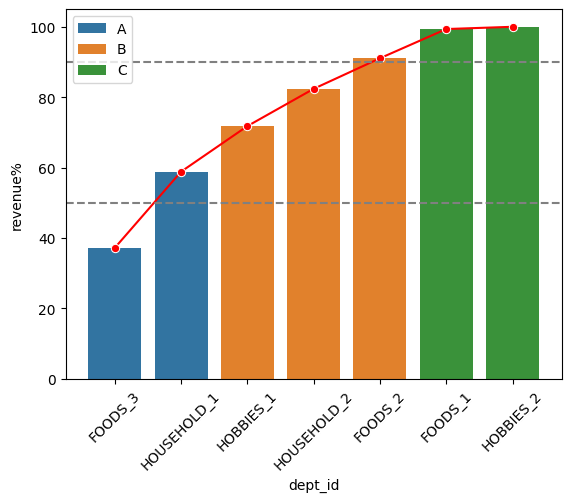

In [ ]:
abc = (
    abc
    .with_columns(
        pl.when(pl.col('dept_id').is_in(['FOODS_3', 'HOUSEHOLD_1']))
        .then(pl.lit('A'))
        .when(pl.col('dept_id').is_in(['HOBBIES_1', 'HOUSEHOLD_2', 'FOODS_2']))
        .then(pl.lit('B'))
        .when(pl.col('dept_id').is_in(['FOODS_1', 'HOBBIES_2']))
        .then(pl.lit('C'))
        .otherwise(pl.lit(None))
        .alias('abc')
    )
)

fig, ax = plt.subplots()

sns.barplot(x='dept_id', y='revenue%', data=abc, ax=ax, hue='abc')
sns.lineplot(x='dept_id', y='revenue%', data=abc, ax=ax, marker='o', color='red', sort=False)
plt.xticks(rotation=45)
ax.axhline(50, color='grey', linestyle='--')
ax.axhline(90, color='grey', linestyle='--')
plt.show()

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'FOODS_1'),
  Text(1, 0, 'HOUSEHOLD_2'),
  Text(2, 0, 'FOODS_3'),
  Text(3, 0, 'HOBBIES_1'),
  Text(4, 0, 'HOUSEHOLD_1'),
  Text(5, 0, 'HOBBIES_2'),
  Text(6, 0, 'FOODS_2')])

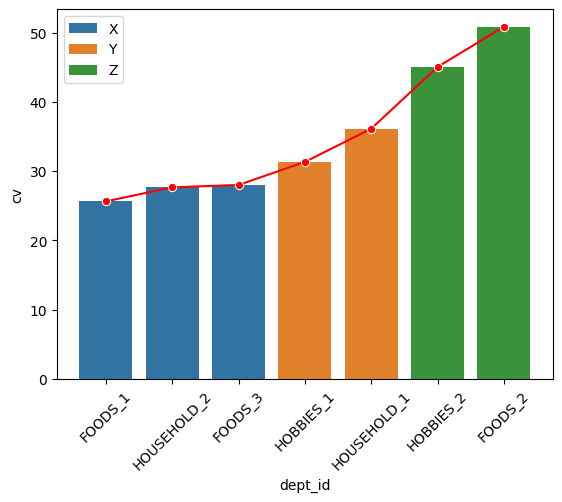

In [36]:
abc_xyz = (
    abc
    .sort('cv')
)
abc_xyz = (
    abc
    .with_columns(
        pl.when(pl.col('dept_id').is_in(['FOODS_1', 'HOUSEHOLD_2', 'FOODS_3']))
        .then(pl.lit('X'))
        .when(pl.col('dept_id').is_in(['HOBBIES_1', 'HOUSEHOLD_1']))
        .then(pl.lit('Y'))
        .when(pl.col('dept_id').is_in(['HOBBIES_2', 'FOODS_2']))
        .then(pl.lit('Z'))
        .otherwise(pl.lit(None))
        .alias('xyz')
    )
    .sort('cv')
)

fig, ax = plt.subplots()

sns.barplot(x='dept_id', y='cv', data=abc_xyz, ax=ax, hue='xyz')
sns.lineplot(x='dept_id', y='cv', data=abc_xyz, ax=ax, marker='o', color='red', sort=False)
plt.xticks(rotation=45)

In [39]:
abc_order = ['A', 'B', 'C']
xyz_order = ['X', 'Y', 'Z']

pdf = abc_xyz.select('dept_id', 'abc', 'xyz').to_pandas()

# build the grid
grid = {}
for a in abc_order:
    for x in xyz_order:
        depts = pdf[(pdf['abc'] == a) & (pdf['xyz'] == x)]['dept_id'].tolist()
        grid[(a, x)] = ', '.join(depts) if depts else '-'

# print as a table
col_width = max(len(v) for v in grid.values()) + 2
header = 'ABC\\XYZ'.ljust(10) + ''.join(x.ljust(col_width) for x in xyz_order)
print(header)
print('-' * len(header))
for a in abc_order:
    row = a.ljust(10) + ''.join(grid[(a, x)].ljust(col_width) for x in xyz_order)
    print(row)

ABC\XYZ   X            Y            Z            
-------------------------------------------------
A         FOODS_3      HOUSEHOLD_1  -            
B         HOUSEHOLD_2  HOBBIES_1    FOODS_2      
C         FOODS_1      -            HOBBIES_2    
